# Phase 2: Virtual Library Expansion, Lipinski Filtering & PAINS Screening

**Objective:** Reproduce the canonical Phase 2 pipeline (`phase2_integration.py`) interactively.

**Workflow:**
1. Generate 16 taloside derivatives (8 building blocks × CuAAC/RuAAC regioisomers)
2. Apply carbohydrate-adjusted Lipinski filtering
3. Screen PAINS alerts via RDKit FilterCatalog
4. Rank Lipinski-passing compounds by composite lead score
5. Export seven CSV files to `phase2_output/`

All library-generation and filtering logic is imported from `taloside_pipeline` — no duplicate implementations in this notebook.

## 1. Setup & Imports

In [1]:
import sys
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Crippen, Descriptors, Lipinski

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("[OK] Standard imports successful")

[OK] Standard imports successful


In [2]:
# Resolve repository root whether the notebook is launched from project root or notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from taloside_pipeline.descriptor_calculator import load_compounds_from_dict
from taloside_pipeline.glycolibrary_generator import (
    LibraryConfig,
    configure_logging,
    generate_triazole_library,
)
from taloside_pipeline.phase2_integration import (
    apply_lipinski_filter,
    apply_pains_filter,
    compute_lead_scores,
)

logger = configure_logging(log_file=repo_root / "phase2_notebook.log")
logger.setLevel(logging.INFO)

print(f"[OK] Pipeline modules imported (repo root: {repo_root})")

[OK] Pipeline modules imported (repo root: C:\Users\adamh\OneDrive - National University of Ireland, Galway\Desktop\taloside-screening-pipeline-master)


## 2. Scaffold, Building Blocks & Configuration

Constants match `run_phase2_pipeline()` in `phase2_integration.py` exactly.

In [3]:
SCAFFOLD = (
    "O=C(O[C@H]1[C@@H](OCN=[N+]=[N-])[C@@H](O)[C@@H](CO)O[C@H]1OC)"
    "C4=C([N+]([O-])=O)C=CC=C4"
)

BUILDING_BLOCKS = [
    {"id": "BB-001-Ph", "smiles": "C#Cc1ccccc1"},
    {"id": "BB-002-4OMe", "smiles": "C#Cc1ccc(OC)cc1"},
    {"id": "BB-003-4Cl", "smiles": "C#Cc1ccc(Cl)cc1"},
    {"id": "BB-004-4F", "smiles": "C#Cc1ccc(F)cc1"},
    {"id": "BB-005-3Br", "smiles": "C#Cc1cc(Br)ccc1"},
    {"id": "BB-006-2NO2", "smiles": "C#Cc1ccccc1[N+](=O)[O-]"},
    {"id": "BB-007-Pyridine", "smiles": "C#Cc1ccccn1"},
    {"id": "BB-008-Furan", "smiles": "C#Cc1ccoc1"},
]

config = LibraryConfig(
    max_products=500,
    min_product_mw=250.0,
    max_product_mw=800.0,
    include_stereoisomers=True,
    filter_hypervalent=True,
    output_dir=repo_root / "phase2_output",
)

scaffold_mol = Chem.MolFromSmiles(SCAFFOLD)
assert scaffold_mol is not None, "Invalid scaffold SMILES"

print(f"Scaffold atoms: {scaffold_mol.GetNumAtoms()}")
print(f"Building blocks: {len(BUILDING_BLOCKS)}")
print(f"Output directory: {config.output_dir}")

Scaffold atoms: 28
Building blocks: 8
Output directory: C:\Users\adamh\OneDrive - National University of Ireland, Galway\Desktop\taloside-screening-pipeline-master\phase2_output


## 3. Run Canonical Pipeline Steps

In [4]:
# Step 1: Generate both CuAAC (1,4) and RuAAC (1,5) regioisomers
library_df = generate_triazole_library(
    scaffold_smiles=SCAFFOLD,
    building_blocks=BUILDING_BLOCKS,
    config=config,
    logger_instance=logger,
)

print(f"Total enumerated products: {len(library_df)}")
print(library_df["regioisomer"].value_counts().to_string())
library_df.head()

[INFO    ] GlycoLibraryGenerator: [OK] Scaffold loaded (28 atoms)


[INFO    ] GlycoLibraryGenerator: [OK] Loaded 8 building blocks


[INFO    ] GlycoLibraryGenerator: ======================================================================


[INFO    ] GlycoLibraryGenerator: INITIATING COMBINATORIAL LIBRARY GENERATION


[INFO    ] GlycoLibraryGenerator: Regioisomer label: '1,4-CuAAC'


...

[INFO    ] GlycoLibraryGenerator: Failed products: 16


[INFO    ] GlycoLibraryGenerator: ======================================================================


[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit valence for atom # 4 N, 3, is greater than permitted
[20:23:36] WARNING: Charges were rearranged; Accepted unusual valence(s): N+1(3); N-1(3)

[20:23:36] Explicit va

Total enumerated products: 16
regioisomer
1,4-CuAAC    8
1,5-RuAAC    8


,compound_id,parent_scaffold_id,building_block_id,regioisomer,product_smiles,product_inchi,product_inchikey,molecular_weight,h_donors,h_acceptors,logp,tpsa,rotatable_bonds,generation_status
0,SCAF-001_BB-001-Ph_1,SCAF-001,BB-001-Ph,"1,4-CuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2[N+]=[N-]...,InChI=1S/C23H24N4O9/c1-33-23-21(36-22(30)15-9-...,IIQAHTYBOFYZDQ-YPSHPOCOSA-N,500.464,2,11,0.6397,169.03,9,success
1,SCAF-001_BB-001-Ph_2,SCAF-001,BB-001-Ph,"1,5-RuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2C=C(C3=CC...,InChI=1S/C23H24N4O9/c1-33-23-21(36-22(30)15-9-...,QNGCXUWBWOXARF-YPSHPOCOSA-N,500.464,2,11,0.6397,169.03,9,success
2,SCAF-001_BB-002-4OMe_1,SCAF-001,BB-002-4OMe,"1,4-CuAAC",COC1=CC=C(C2=C[N-]=[N+]N2CO[C@H]2[C@@H](O)[C@@...,InChI=1S/C24H26N4O10/c1-34-15-9-7-14(8-10-15)1...,ZVBMRGHNYQZKDA-XALOWKIYSA-N,530.490,2,12,0.6138,178.26,10,success
3,SCAF-001_BB-002-4OMe_2,SCAF-001,BB-002-4OMe,"1,5-RuAAC",COC1=CC=C(C2=CN(CO[C@H]3[C@@H](O)[C@@H](CO)O[C...,InChI=1S/C24H26N4O10/c1-34-15-9-7-14(8-10-15)1...,QQNAKVZIKGCRPW-XALOWKIYSA-N,530.490,2,12,0.6138,178.26,10,success
4,SCAF-001_BB-003-4Cl_1,SCAF-001,BB-003-4Cl,"1,4-CuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2[N+]=[N-]...,InChI=1S/C23H23ClN4O9/c1-34-23-21(37-22(31)15-...,DMKFGNKODDCTLP-YPSHPOCOSA-N,534.909,2,11,1.2062,169.03,9,success


In [5]:
# Step 2: Lipinski filtering (carbohydrate-adjusted thresholds)
lipinski_passed, lipinski_failed = apply_lipinski_filter(library_df, strict_mode=True)

print(f"Lipinski passed: {len(lipinski_passed)} / {len(library_df)}")
print(f"Lipinski failed: {len(lipinski_failed)}")

[INFO    ] GlycoLibraryGenerator: [OK] Lipinski filtering (carbohydrate-adjusted thresholds):


[INFO    ] GlycoLibraryGenerator:   MW ≤600 | LogP ≤4.0 | HBD ≤6 | HBA ≤12


[INFO    ] GlycoLibraryGenerator:   Passed: 14  Failed: 2  Pass rate: 87.5%


Lipinski passed: 14 / 16
Lipinski failed: 2


In [6]:
# Step 3: PAINS screening on Lipinski-passing compounds
clean_df, pains_df, undetermined_df = apply_pains_filter(lipinski_passed)

print(f"PAINS clean:       {len(clean_df)}")
print(f"PAINS flagged:     {len(pains_df)}")
print(f"PAINS undetermined:{len(undetermined_df)}")

[INFO    ] GlycoLibraryGenerator: Screening library for PAINS (RDKit FilterCatalog PAINS_A/B/C)...


[INFO    ] GlycoLibraryGenerator: Initialising RDKit PAINS catalog...


[INFO    ] GlycoLibraryGenerator:   Loaded PAINS catalog (480 entries)


[INFO    ] GlycoLibraryGenerator: [OK] PAINS screening complete:


[INFO    ] GlycoLibraryGenerator:   Clean (no PAINS):  14


[INFO    ] GlycoLibraryGenerator:   Flagged (PAINS):   0


[INFO    ] GlycoLibraryGenerator:   UNDETERMINED:      0  ← see 06_pains_undetermined.csv


PAINS clean:       14
PAINS flagged:     0
PAINS undetermined:0


In [7]:
# Step 4: Lead scoring (same merge logic as phase2_integration.py)
scored_df = compute_lead_scores(lipinski_passed)

pains_status_map = {
    row["compound_id"]: row.get("pains_status", "")
    for _, row in pd.concat([clean_df, pains_df, undetermined_df]).iterrows()
}
if pains_status_map:
    scored_df = scored_df.merge(
        pd.Series(pains_status_map, name="pains_status").rename_axis("compound_id").reset_index(),
        on="compound_id",
        how="left",
    )

print(f"Lead score range: {scored_df['lead_score'].min():.3f} – {scored_df['lead_score'].max():.3f}")
scored_df.head()

Lead score range: 0.377 – 0.873


,compound_id,parent_scaffold_id,building_block_id,regioisomer,product_smiles,product_inchi,product_inchikey,molecular_weight,h_donors,h_acceptors,logp,tpsa,rotatable_bonds,generation_status,lead_score,pains_status
0,SCAF-001_BB-001-Ph_1,SCAF-001,BB-001-Ph,"1,4-CuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2[N+]=[N-]...,InChI=1S/C23H24N4O9/c1-33-23-21(36-22(30)15-9-...,IIQAHTYBOFYZDQ-YPSHPOCOSA-N,500.464,2,11,0.6397,169.03,9,success,0.873410,CLEAN
1,SCAF-001_BB-001-Ph_2,SCAF-001,BB-001-Ph,"1,5-RuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2C=C(C3=CC...,InChI=1S/C23H24N4O9/c1-33-23-21(36-22(30)15-9-...,QNGCXUWBWOXARF-YPSHPOCOSA-N,500.464,2,11,0.6397,169.03,9,success,0.873410,CLEAN
2,SCAF-001_BB-004-4F_2,SCAF-001,BB-004-4F,"1,5-RuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2C=C(C3=CC...,InChI=1S/C23H23FN4O9/c1-34-23-21(37-22(31)15-4...,XGYJEURCTJLFDQ-YPSHPOCOSA-N,518.454,2,11,0.9369,169.03,9,success,0.768604,CLEAN
3,SCAF-001_BB-004-4F_1,SCAF-001,BB-004-4F,"1,4-CuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2[N+]=[N-]...,InChI=1S/C23H23FN4O9/c1-34-23-21(37-22(31)15-4...,FZTKEJKHPLQBQM-YPSHPOCOSA-N,518.454,2,11,0.9369,169.03,9,success,0.768604,CLEAN
4,SCAF-001_BB-008-Furan_2,SCAF-001,BB-008-Furan,"1,5-RuAAC",CO[C@@H]1O[C@H](CO)[C@H](O)[C@H](OCN2C=C(C3=CO...,InChI=1S/C21H22N4O10/c1-31-21-19(35-20(28)13-4...,FEVWSDKJXZMNCW-QFCZJPRCSA-N,490.425,2,12,0.0151,178.26,9,success,0.701294,CLEAN


In [8]:
# Step 5: Export all seven CSV files (same names as phase2_integration.py)
config.output_dir.mkdir(parents=True, exist_ok=True)

exports = [
    (library_df, "01_all_generated_compounds.csv"),
    (lipinski_passed, "02_lipinski_passed.csv"),
    (lipinski_failed, "03_lipinski_failed.csv"),
    (clean_df, "04_lipinski_clean_no_pains.csv"),
    (pains_df, "05_lipinski_with_pains.csv"),
    (undetermined_df, "06_pains_undetermined.csv"),
    (scored_df, "07_lead_scored.csv"),
]

for df_export, fname in exports:
    path = config.output_dir / fname
    df_export.to_csv(path, index=False)
    print(f"[OK] {fname} ({len(df_export)} compounds)")

[OK] 01_all_generated_compounds.csv (16 compounds)
[OK] 02_lipinski_passed.csv (14 compounds)
[OK] 03_lipinski_failed.csv (2 compounds)
[OK] 04_lipinski_clean_no_pains.csv (14 compounds)
[OK] 05_lipinski_with_pains.csv (0 compounds)
[OK] 06_pains_undetermined.csv (0 compounds)
[OK] 07_lead_scored.csv (14 compounds)


## 4. Descriptive Statistics

In [9]:
descriptor_cols = [
    "molecular_weight", "logp", "h_donors", "h_acceptors", "tpsa", "rotatable_bonds"
]
print("Library descriptor summary:")
display(library_df[descriptor_cols].describe().round(2))

print("\nProducts per building block:")
display(library_df.groupby(["building_block_id", "regioisomer"]).size().unstack(fill_value=0))

Library descriptor summary:


,molecular_weight,logp,h_donors,h_acceptors,tpsa,rotatable_bonds
count,16.00,16.00,16.0,16.00,16.00,16.00
mean,525.13,0.64,2.0,11.62,178.28,9.25
std,28.04,0.48,0.0,0.72,14.14,0.45
min,490.43,0.02,2.0,11.00,169.03,9.00
25%,501.21,0.21,2.0,11.00,169.03,9.00
50%,524.47,0.63,2.0,11.50,173.65,9.00
75%,537.55,1.00,2.0,12.00,179.04,9.25
max,579.36,1.36,2.0,13.00,212.17,10.00



Products per building block:


regioisomer,"1,4-CuAAC","1,5-RuAAC"
building_block_id,,
BB-001-Ph,1,1
BB-002-4OMe,1,1
BB-003-4Cl,1,1
BB-004-4F,1,1
BB-005-3Br,1,1
BB-006-2NO2,1,1
BB-007-Pyridine,1,1
BB-008-Furan,1,1


## 5. Visualizations

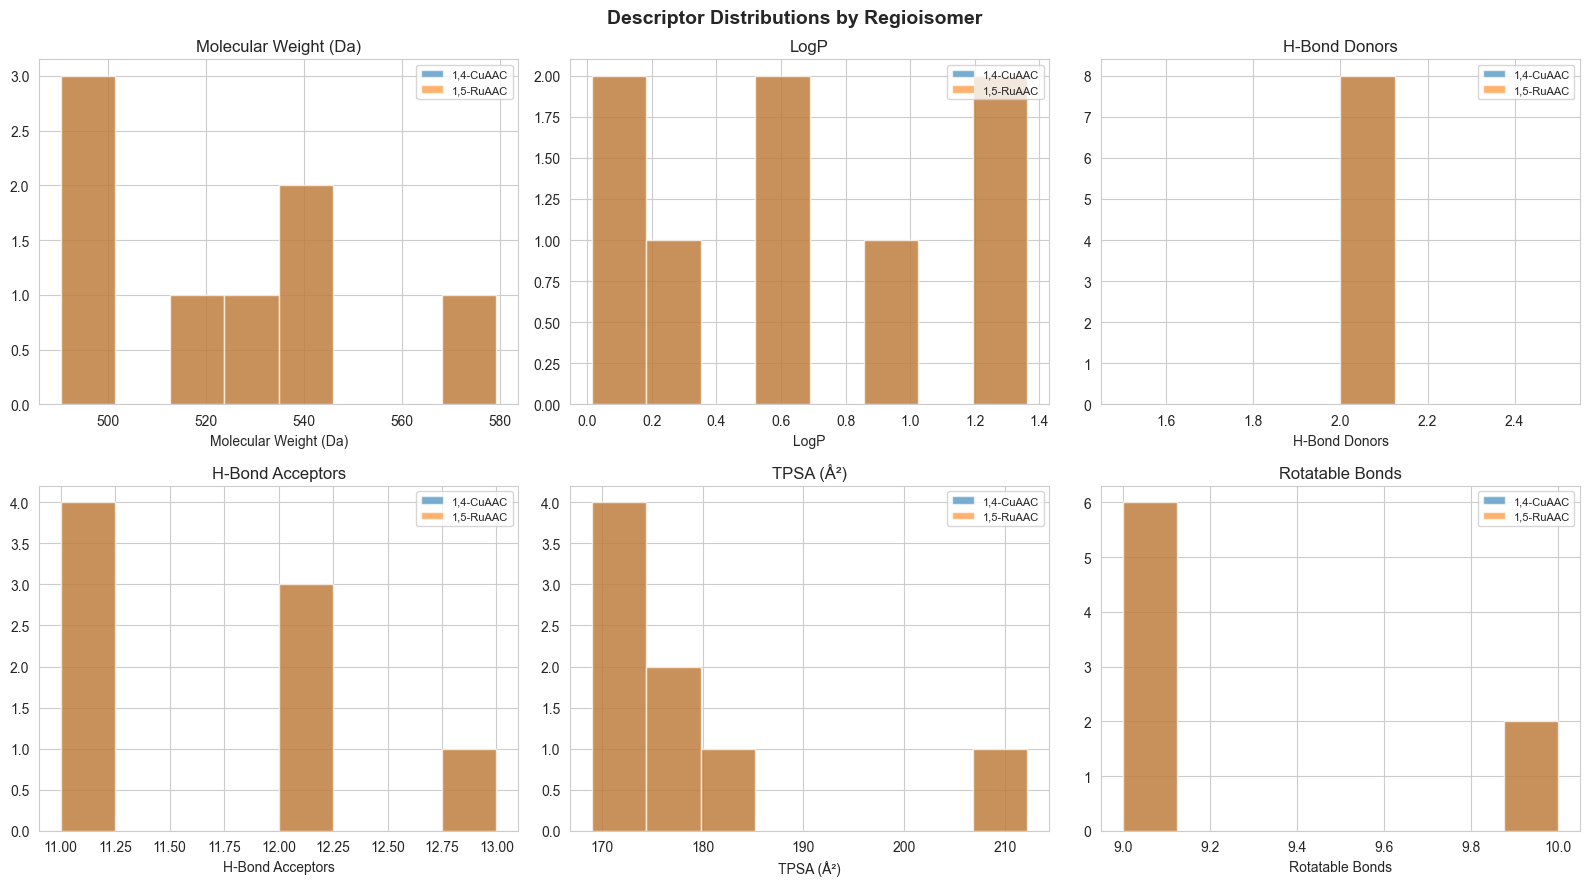

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("molecular_weight", "Molecular Weight (Da)"),
    ("logp", "LogP"),
    ("h_donors", "H-Bond Donors"),
    ("h_acceptors", "H-Bond Acceptors"),
    ("tpsa", "TPSA (Å²)"),
    ("rotatable_bonds", "Rotatable Bonds"),
]

for ax, (col, label) in zip(axes.flat, plot_specs):
    for regio, sub in library_df.groupby("regioisomer"):
        ax.hist(sub[col], bins=8, alpha=0.6, label=regio)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.legend(fontsize=8)

plt.suptitle("Descriptor Distributions by Regioisomer", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(repo_root / "phase2_output" / "descriptor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

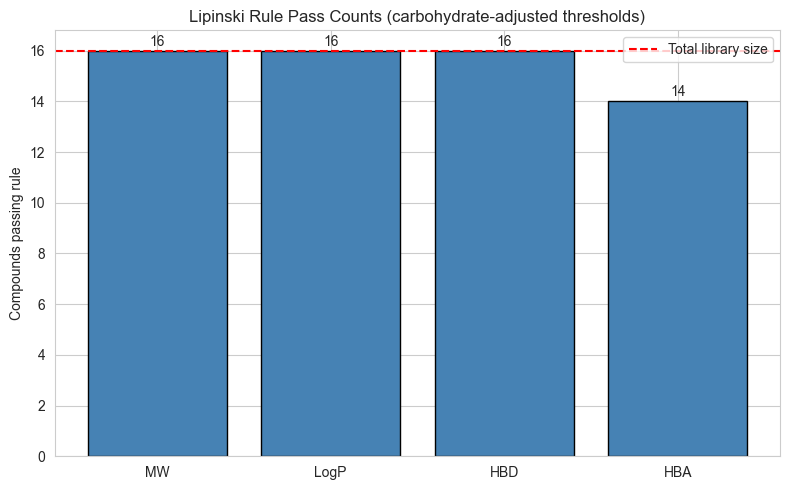

In [11]:
# Lipinski pass/fail counts (visualisation only; thresholds match apply_lipinski_filter strict_mode)
thresholds = {"MW": 600, "LogP": 4.0, "HBD": 6, "HBA": 12}
rule_counts = {
    "MW": (library_df["molecular_weight"] <= thresholds["MW"]).sum(),
    "LogP": (library_df["logp"] <= thresholds["LogP"]).sum(),
    "HBD": (library_df["h_donors"] <= thresholds["HBD"]).sum(),
    "HBA": (library_df["h_acceptors"] <= thresholds["HBA"]).sum(),
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rule_counts.keys(), rule_counts.values(), color="steelblue", edgecolor="black")
ax.axhline(len(library_df), color="red", linestyle="--", label="Total library size")
ax.set_ylabel("Compounds passing rule")
ax.set_title("Lipinski Rule Pass Counts (carbohydrate-adjusted thresholds)")
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, int(bar.get_height()), ha="center")
plt.tight_layout()
plt.savefig(repo_root / "phase2_output" / "lipinski_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

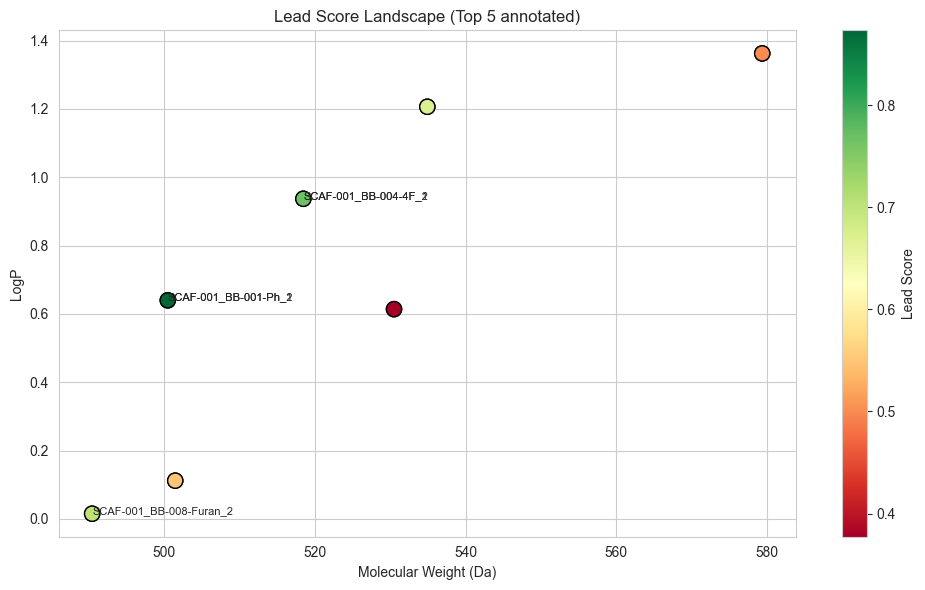

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    scored_df["molecular_weight"],
    scored_df["logp"],
    c=scored_df["lead_score"],
    cmap="RdYlGn",
    s=120,
    edgecolors="black",
)
plt.colorbar(scatter, ax=ax, label="Lead Score")
for _, row in scored_df.head(5).iterrows():
    ax.annotate(row["compound_id"], (row["molecular_weight"], row["logp"]), fontsize=8)
ax.set_xlabel("Molecular Weight (Da)")
ax.set_ylabel("LogP")
ax.set_title("Lead Score Landscape (Top 5 annotated)")
plt.tight_layout()
plt.savefig(repo_root / "phase2_output" / "lead_score_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Comparison: Original MSc Talosides vs Generated Library

In [13]:
original_rows = []
for name, smiles in load_compounds_from_dict().items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue
    original_rows.append({
        "compound_id": name,
        "type": "Original (MSc)",
        "molecular_weight": Descriptors.MolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "h_donors": Lipinski.NumHDonors(mol),
        "h_acceptors": Lipinski.NumHAcceptors(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
    })

original_df = pd.DataFrame(original_rows)
generated_summary = library_df[descriptor_cols].mean()
original_summary = original_df[descriptor_cols].mean()

comparison = pd.DataFrame({"Original (n=10)": original_summary, "Generated (n=16)": generated_summary})
comparison["Difference (Gen − Orig)"] = comparison["Generated (n=16)"] - comparison["Original (n=10)"]
display(comparison.round(2))

,Original (n=10),Generated (n=16),Difference (Gen − Orig)
molecular_weight,536.79,525.13,-11.67
logp,1.26,0.64,-0.62
h_donors,2.10,2.00,-0.10
h_acceptors,11.50,11.62,0.12
tpsa,174.96,178.28,3.32
rotatable_bonds,9.30,9.25,-0.05


## 7. Summary

In [14]:
total = len(library_df)
print("=" * 80)
print("PHASE 2 NOTEBOOK SUMMARY (canonical pipeline workflow)")
print("=" * 80)
print(f"Total enumerated:        {total}")
print(f"  1,4-CuAAC products:    {(library_df['regioisomer'] == '1,4-CuAAC').sum()}")
print(f"  1,5-RuAAC products:    {(library_df['regioisomer'] == '1,5-RuAAC').sum()}")
print(f"Lipinski passed:         {len(lipinski_passed)} ({100 * len(lipinski_passed) / total:.1f}%)")
print(f"Lipinski failed:         {len(lipinski_failed)}")
print(f"PAINS clean:             {len(clean_df)}")
print(f"PAINS flagged:           {len(pains_df)}")
print(f"PAINS undetermined:      {len(undetermined_df)}")
print(f"Top lead:                {scored_df.iloc[0]['compound_id']} (score={scored_df.iloc[0]['lead_score']:.3f})")
print(f"\nExports written to:     {config.output_dir}")

PHASE 2 NOTEBOOK SUMMARY (canonical pipeline workflow)
Total enumerated:        16
  1,4-CuAAC products:    8
  1,5-RuAAC products:    8
Lipinski passed:         14 (87.5%)
Lipinski failed:         2
PAINS clean:             14
PAINS flagged:           0
PAINS undetermined:      0
Top lead:                SCAF-001_BB-001-Ph_1 (score=0.873)

Exports written to:     C:\Users\adamh\OneDrive - National University of Ireland, Galway\Desktop\taloside-screening-pipeline-master\phase2_output


## Appendix: Session Information & Reproducibility

In [15]:
from rdkit import __version__ as rdkit_version

print("ENVIRONMENT & REPRODUCIBILITY")
print("=" * 80)
print(f"Python version:     {sys.version.split()[0]}")
print(f"RDKit version:      {rdkit_version}")
print(f"Pandas version:     {pd.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version:    {sns.__version__}")
print(f"Repository root:    {repo_root}")
print(f"Notebook path:      notebooks/Phase2_VirtualLibraryExpansion.ipynb")
print(f"Pipeline module:    taloside_pipeline.phase2_integration")
print("=" * 80)

ENVIRONMENT & REPRODUCIBILITY
Python version:     3.14.5
RDKit version:      2026.03.2
Pandas version:     3.0.3
NumPy version:      2.4.6
Matplotlib version: 3.10.9
Seaborn version:    0.13.2
Repository root:    C:\Users\adamh\OneDrive - National University of Ireland, Galway\Desktop\taloside-screening-pipeline-master
Notebook path:      notebooks/Phase2_VirtualLibraryExpansion.ipynb
Pipeline module:    taloside_pipeline.phase2_integration
